## Data Preparation & Temporal Alignment

##### Date Synthesis: 
Combining the year and month strings into a single Date object (setting every entry to the 1st of the month).

#### Chronological Sorting:
 Ensuring the data flows from 1999 to 2024.

#### Naming Consistency: 
Simplifying the long, complex column names (like value_coffee_(kshs._millions)) to make our plotting code cleaner and less prone to typos.

In [4]:
# 1. Load Libraries in the same cell
library(tidyverse)
library(lubridate)
library(scales)

# 2. Define Directories (Using your established BASE_DIR logic)
base_dir <- "../../"
clean_data_path <- file.path(base_dir, "data", "cleaned")
export_file <- file.path(clean_data_path, "principal_exports.csv")

# 3. Read and Clean using explicit namespacing (dplyr::)
df_exports_raw <- read.csv(export_file, stringsAsFactors = FALSE)

df_exports <- df_exports_raw %>%
  # Create a proper Date column
  dplyr::mutate(date = as.Date(paste(year, month, "01", sep = "-"), format = "%Y-%B-%d")) %>%
  # Rename columns using explicit dplyr::rename
  dplyr::rename(
    coffee_vol   = volume_coffee_.tonnes.,
    coffee_val   = value_coffee_.kshs._millions.,
    coffee_price = average_coffee_.kshs._per_tonne.,
    tea_vol      = volume_tea__.tonnes.,
    tea_val      = value_tea_.kshs._millions.,
    tea_price    = average_tea_.kshs._per_tonne.,
    hort_vol     = volume_horticulture__.tonnes.,
    hort_val     = value_horticulture_.kshs._millions.,
    hort_price   = average_horticulture_.kshs._per_tonne.
  ) %>%
  # Use explicit dplyr::arrange to solve your error
  dplyr::arrange(date)

# Verify results
print("Cleaned Data Preview:")
head(df_exports)

[1] "Cleaned Data Preview:"


,year,month,coffee_vol,coffee_val,coffee_price,tea_vol,tea_val,tea_price,hort_vol,hort_val,hort_price,date
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>
1,1998,August,2759.82,500.47,181341.8,22020.91,2404.70,109200.6,18002.57,854.04,47440.12,1998-08-01
2,1998,September,3243.70,536.21,165306.9,22651.29,2564.06,113197.0,30602.80,1446.75,47275.08,1998-09-01
3,1998,October,4158.57,584.32,140509.6,21915.84,2450.01,111791.8,29433.70,1659.82,56391.98,1998-10-01
4,1998,November,3958.47,578.74,146201.9,21317.36,2295.48,107681.3,13216.28,1295.53,98025.09,1998-11-01
5,1998,December,3565.01,574.54,161159.7,20153.53,2129.77,105677.5,11577.62,1491.47,128823.37,1998-12-01
6,1999,January,1461.38,224.79,153821.3,21531.31,2393.41,111159.5,6599.12,1346.01,203967.76,1999-01-01


## 1.The 'Big Three' Value Composition
This analysis answers: **How much total foreign exchange are these three crops bringing in, and who is the leader?** I will use a **Stacked Area Chart.** 

The total height represents the total monthly value earned by Kenya from these three primary agricultural exports. 

The colored bands show the relative contribution of each.

R

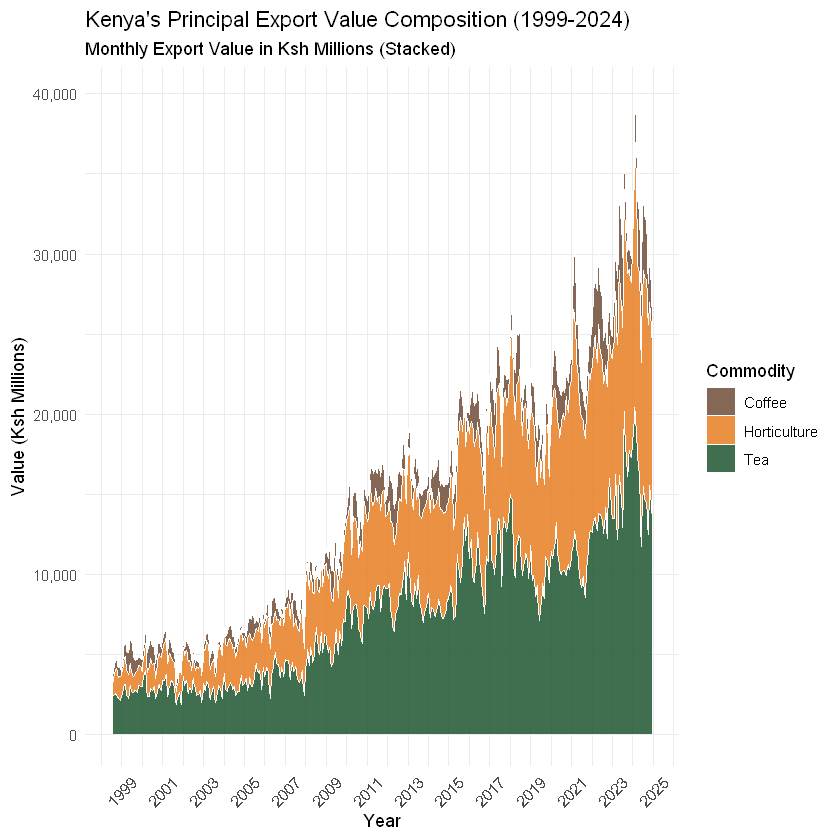

In [5]:
# 1. Reshape data (Pivot from Wide to Long)
df_long_val <- df_exports %>%
  dplyr::select(date, coffee_val, tea_val, hort_val) %>%
  tidyr::pivot_longer(cols = -date, names_to = "Commodity", values_to = "Value")

# 2. Plotting with specific colors
ggplot(df_long_val, aes(x = date, y = Value, fill = Commodity)) +
  geom_area(alpha = 0.85, color = "white", linewidth = 0.1) +
  scale_fill_manual(
    values = c("coffee_val" = "#6F4E37", "tea_val" = "#1E5631", "hort_val" = "#E67E22"),
    labels = c("Coffee", "Horticulture", "Tea")
  ) +
  scale_y_continuous(labels = scales::label_comma()) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  labs(
    title = "Kenya's Principal Export Value Composition (1999-2024)",
    subtitle = "Monthly Export Value in Ksh Millions (Stacked)",
    x = "Year", y = "Value (Ksh Millions)",
    fill = "Commodity"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 0.5))

## Key Insights to Observe
#### The Rise of Horticulture
 In the late 90s and early 2000s, Tea was the dominant giant. Observe how the orange band (Horticulture) grows significantly over the last decade, often rivaling Tea in value.

#### Coffee’s Stagnation
 Notice that Coffee (the brown band) has remained relatively thin compared to the other two, showing that while it’s a premium product, it hasn't scaled in volume/value at the same rate.

 #### Seasonal Spikes
  Agriculture is cyclical. Observe the distinct vertical waves that correspond to harvest seasons (like the tea-plucking peaks).

#### Currency Impact
 Note the sharp increase in nominal Ksh values starting around 2022. This spike is partly driven by the significant depreciation of the Kenya Shilling; since these exports are sold in Dollars, the "Ksh Million" equivalent jumps even if the physical volume didn't.

## 2. Unit Price Comparison (Price per Tonne)
We are comparing the average_price per tonne for Coffee, Tea, and Horticulture.

**Goal:** To see which crop is "moving up the value chain." If the price per tonne is rising steadily, it suggests Kenya is exporting higher-quality (premium) products or benefiting from strong global demand.

**Why it matters:** If volumes are increasing but prices are falling, the economy is working harder for less money.

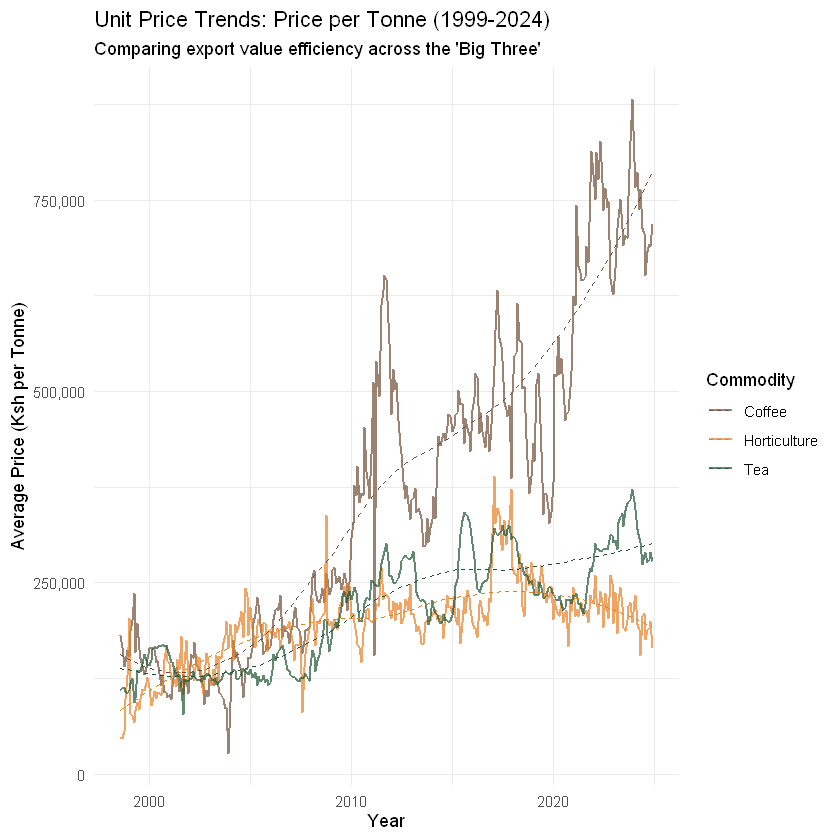

In [11]:
# 1. Reshape Price Data
df_long_price <- df_exports %>%
  dplyr::select(date, coffee_price, tea_price, hort_price) %>%
  tidyr::pivot_longer(cols = -date, names_to = "Commodity", values_to = "Price_Per_Tonne")

# 2. Plotting Unit Prices with updated syntax
ggplot(df_long_price, aes(x = date, y = Price_Per_Tonne, color = Commodity)) +
  geom_line(linewidth = 0.8, alpha = 0.7) +
  # Adding a trend line with explicit formula to remove the second warning
  geom_smooth(method = "loess", formula = y ~ x, se = FALSE, linetype = "dashed", linewidth = 0.5) +
  scale_color_manual(
    values = c("coffee_price" = "#6F4E37", "tea_price" = "#1E5631", "hort_price" = "#E67E22"),
    labels = c("Coffee", "Horticulture", "Tea")
  ) +
  scale_y_continuous(labels = scales::label_comma()) +
  labs(
    title = "Unit Price Trends: Price per Tonne (1999-2024)",
    subtitle = "Comparing export value efficiency across the 'Big Three'",
    x = "Year", y = "Average Price (Ksh per Tonne)",
    color = "Commodity"
  ) +
  theme_minimal()

## 3. The Correlation between Volume and Price

A more advanced analysis step here, I want to see if there is an inverse relationship between how much Kenya produces (Volume) and the price it gets (Price).

The Logic behind is that often, when there is a **'bumper harvest' (high volume)**, global prices drop. 

My focus on Tea, as it is Kenya's most consistent export.

`geom_smooth()` using formula = 'y ~ x'


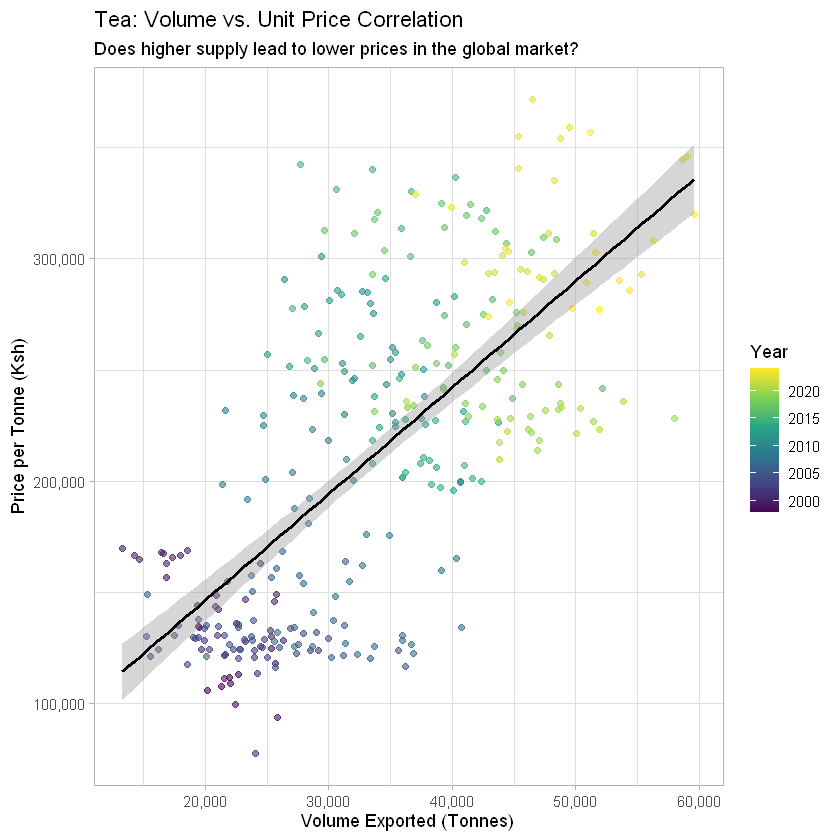

In [7]:
# Focus on Tea: Volume vs Price
ggplot(df_exports, aes(x = tea_vol, y = tea_price)) +
  geom_point(aes(color = year), alpha = 0.6) +
  geom_smooth(method = "lm", color = "black") + # Linear regression line
  scale_color_viridis_c() +
  scale_x_continuous(labels = scales::label_comma()) +
  scale_y_continuous(labels = scales::label_comma()) +
  labs(
    title = "Tea: Volume vs. Unit Price Correlation",
    subtitle = "Does higher supply lead to lower prices in the global market?",
    x = "Volume Exported (Tonnes)", y = "Price per Tonne (Ksh)",
    color = "Year"
  ) +
  theme_light()

## Seasonal Heatmap-The Monthly Pulse

**The Goal**
 To see if certain months consistently produce more across all 25 years.


#### Coffee’s Striping 
You might see horizontal "stripes" where certain months (often early in the year) are consistently darker. This marks the primary "Main Crop" harvest versus the "Fly Crop."

#### Horticulture’s Expansion
Unlike the others, the Horticulture heatmap gets darker and darker as you move from left (1999) to right (2024). This visually proves the structural growth of the sector rather than just seasonal fluctuation.

#### Production Shocks
Look out for vertical white lines—years where all months are light. These represent major national droughts or global logistics shutdowns (like early 2020) that affected all exports simultaneously.

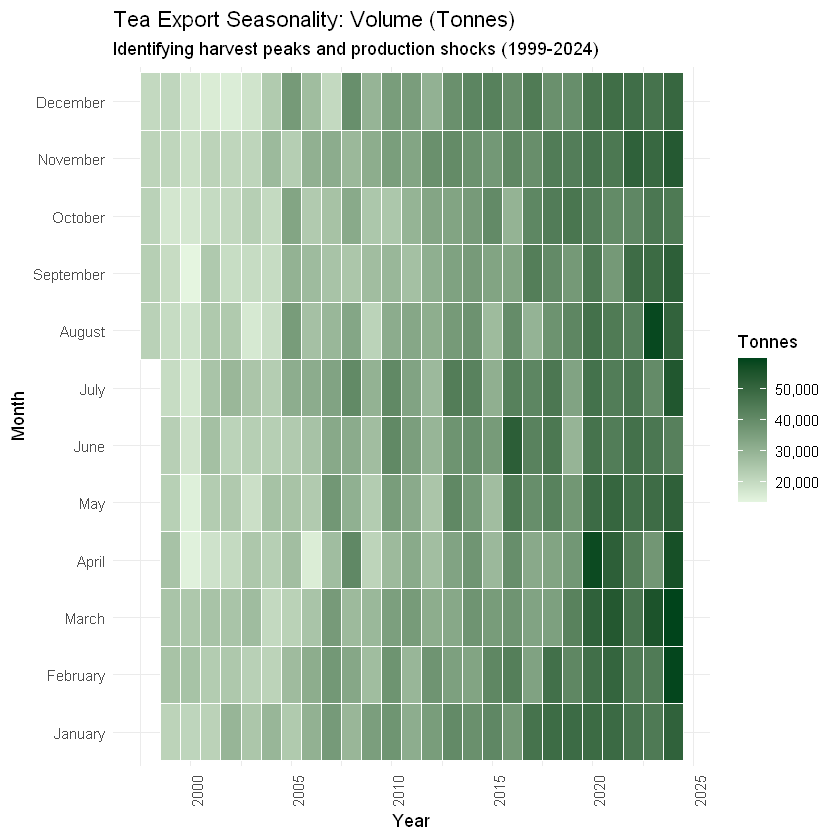

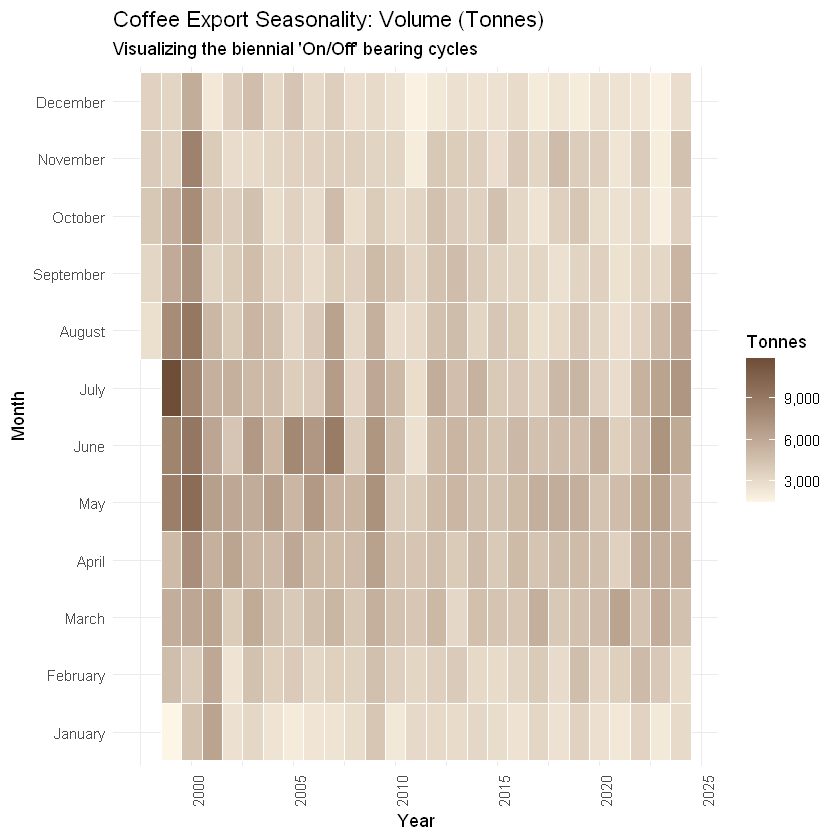

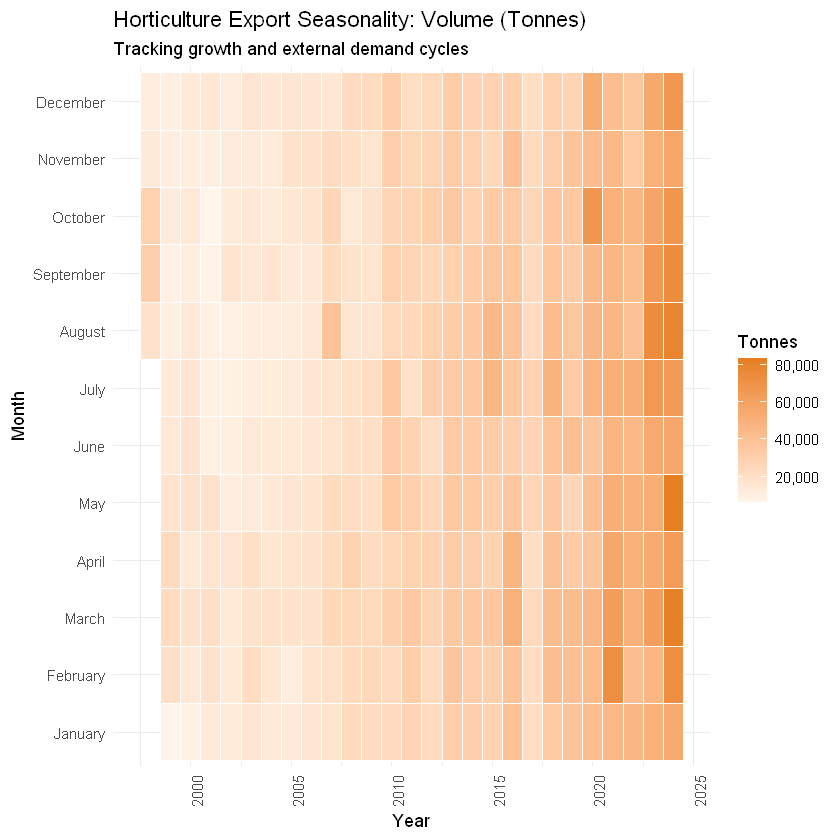

In [10]:
# . Ensure months are factors in the correct calendar order (if not already done)
df_seasonal <- df_exports %>%
  dplyr::mutate(month = factor(month, levels = month.name))

# 1. Plotting the Heatmap for Tea Volume
ggplot(df_seasonal, aes(x = year, y = month, fill = tea_vol)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "#e5f5e0", high = "#00441b", labels = scales::label_comma()) +
  labs(
    title = "Tea Export Seasonality: Volume (Tonnes)",
    subtitle = "Identifying harvest peaks and production shocks (1999-2024)",
    x = "Year", y = "Month",
    fill = "Tonnes"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90))

# 3. Coffee Seasonality Heatmap
plot_coffee_seasonal <- ggplot(df_seasonal, aes(x = year, y = month, fill = coffee_vol)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "#fdf5e6", high = "#6F4E37", labels = scales::label_comma()) +
  labs(
    title = "Coffee Export Seasonality: Volume (Tonnes)",
    subtitle = "Visualizing the biennial 'On/Off' bearing cycles",
    x = "Year", y = "Month", fill = "Tonnes"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90))

# 4. Horticulture Seasonality Heatmap
plot_hort_seasonal <- ggplot(df_seasonal, aes(x = year, y = month, fill = hort_vol)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "#fff5eb", high = "#E67E22", labels = scales::label_comma()) +
  labs(
    title = "Horticulture Export Seasonality: Volume (Tonnes)",
    subtitle = "Tracking growth and external demand cycles",
    x = "Year", y = "Month", fill = "Tonnes"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90))

# Display the plots
print(plot_coffee_seasonal)
print(plot_hort_seasonal)

## Insights
#### Price Volatility
Coffee remains a high-value but unstable asset, while Tea provides a consistent "floor" for the economy.

#### The Horticulture Strategy
 Horticulture prices are rising alongside volumes, it means Kenya is successfully diversifying into high-value crops (like flowers and avocados).
